In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 1. Inspección y Estructura de los Datos
Antes de graficar, revisaremos las dimensiones del dataset, el tipo de datos de cada columna y si existen valores nulos.

In [2]:
df = pd.read_csv('../data/clean/Internship_Selection_Dataset.csv')

df.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [3]:
print("--- Información del Dataset ---")
df.info()

print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  str    
 10  college_tier             10000 non-null  str    
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  gi

In [4]:
df.describe()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


In [5]:
df.describe(include='str')

,extracurricular,college_tier,placement_training
count,10000,10000,10000
unique,2,3,2
top,Yes,Tier 2,Yes
freq,6025,4944,6876


In [6]:
# conversión de las columnas extracurricuilar y placement_training en tipo bool
df['extracurricular'] = df['extracurricular'].map(
    {'Yes':True, 'No': False}
).astype(bool)
df['placement_training'] = df['placement_training'].map(
    {'Yes':True, 'No':False}
).astype(bool)

## 2. Análisis Univariado (Distribución de variables individuales)
Analizaremos la distribución de la variable objetivo (`selected`) y de métricas clave como el promedio académico (`CGPA`) y el nivel de universidad (`college_tier`).

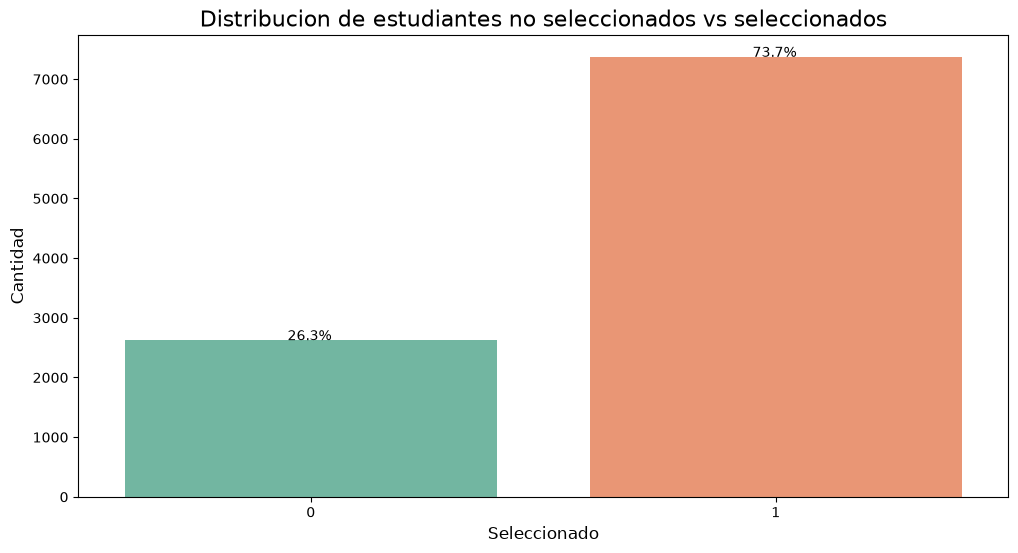

In [7]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='selected', data=df, palette='Set2', legend=False, hue='selected')
plt.title('Distribucion de estudiantes no seleccionados vs seleccionados', fontsize=16)
plt.xlabel('Seleccionado', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
total = len(df)
for p in ax.patches:
    porcentaje = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(porcentaje, (x, y))

plt.show()


### 💡 Interpretación de la Variable Objetivo (`selected`)
Como podemos observar en el gráfico de barras, nos encontramos ante un dataset **moderadamente desbalanceado**. 
- Aproximadamente el **73.7%** de los estudiantes en este registro fueron seleccionados para la pasantía, mientras que el **26.3%** no lo logró.
- **Implicaciones para el modelo:** Al tener más ejemplos de casos "Seleccionados", los algoritmos de Machine Learning podrían sesgarse ligeramente a predecir esta clase. Aunque el desbalance no es extremo (como en casos de detección de fraude), es un factor importante a considerar al momento de evaluar futuros modelos predictivos. Métricas como *F1-Score* o *Recall* serán más útiles que la simple *Accuracy* (Exactitud).

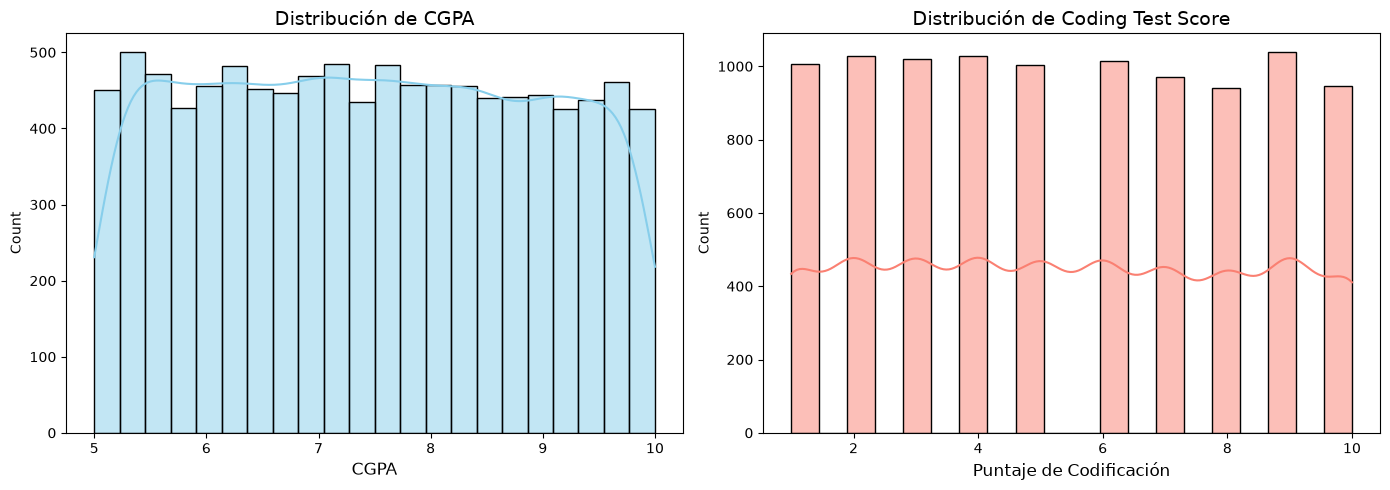

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['CGPA'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de CGPA', fontsize=14)
axes[0].set_xlabel('CGPA', fontsize=12)

sns.histplot(df['coding_test_score'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Coding Test Score', fontsize=14)
axes[1].set_xlabel('Puntaje de Codificación', fontsize=12)

plt.tight_layout()
plt.show()


### 💡 Interpretación de Distribuciones Numéricas
- **Distribución del CGPA:** El promedio académico de los estudiantes parece seguir una distribución relativamente normal (forma de campana), concentrando a la mayoría de los estudiantes en promedios medios-altos. 
- **Distribución del Puntaje de Codificación:** A diferencia del CGPA, los puntajes de las pruebas de programación tienen una distribución mucho más dispersa y menos centralizada. Esto indica que hay una gran varianza en las habilidades técnicas de los aplicantes; tenemos tanto estudiantes con habilidades muy básicas como estudiantes altamente capacitados, sin un consenso central tan fuerte como en las notas de la universidad.

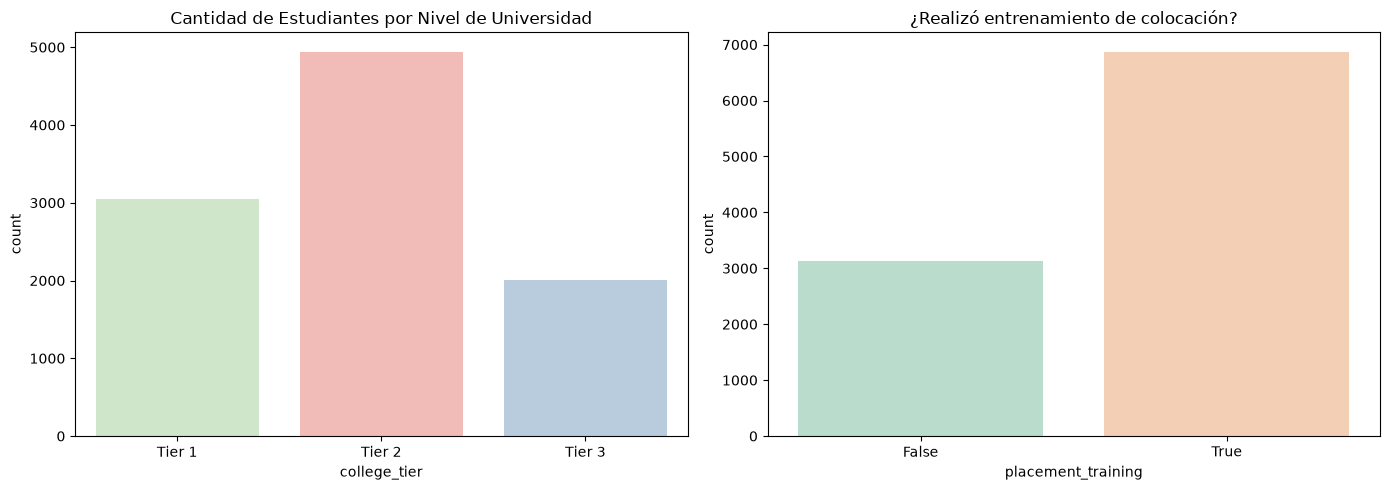

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='college_tier', data=df, ax=axes[0], palette='Pastel1', hue='college_tier', legend=False, order=['Tier 1', 'Tier 2', 'Tier 3'])
axes[0].set_title('Cantidad de Estudiantes por Nivel de Universidad')

sns.countplot(x='placement_training', data=df, ax=axes[1], palette='Pastel2', hue='placement_training', legend=False)
axes[1].set_title('¿Realizó entrenamiento de colocación?')

plt.tight_layout()
plt.show()


### 💡 Interpretación del Perfil Demográfico/Estudiantil
- **Nivel de Universidad (College Tier):** La mayoría de los candidatos provienen de universidades **Tier 2**, seguidos por el Tier 1 y finalmente el Tier 3. Será interesante ver más adelante si pertenecer a un Tier 1 garantiza una mayor tasa de aceptación.
- **Entrenamiento de Colocación (Placement Training):** Una abrumadora mayoría de los estudiantes (más del 68%) tomó cursos o entrenamientos de preparación para inserción laboral. Esto sugiere un perfil de estudiante proactivo y enfocado en conseguir pasantías.

## 3. Análisis Bivariado y Multivariado (Relaciones con la Selección)
Investigaremos cómo interactúan las variables con la decisión final de selección (`selected`).

C:\Users\danie\AppData\Local\Temp\ipykernel_19680\3903788738.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No Seleccionado', 'Seleccionado'])
C:\Users\danie\AppData\Local\Temp\ipykernel_19680\3903788738.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No Seleccionado', 'Seleccionado'])


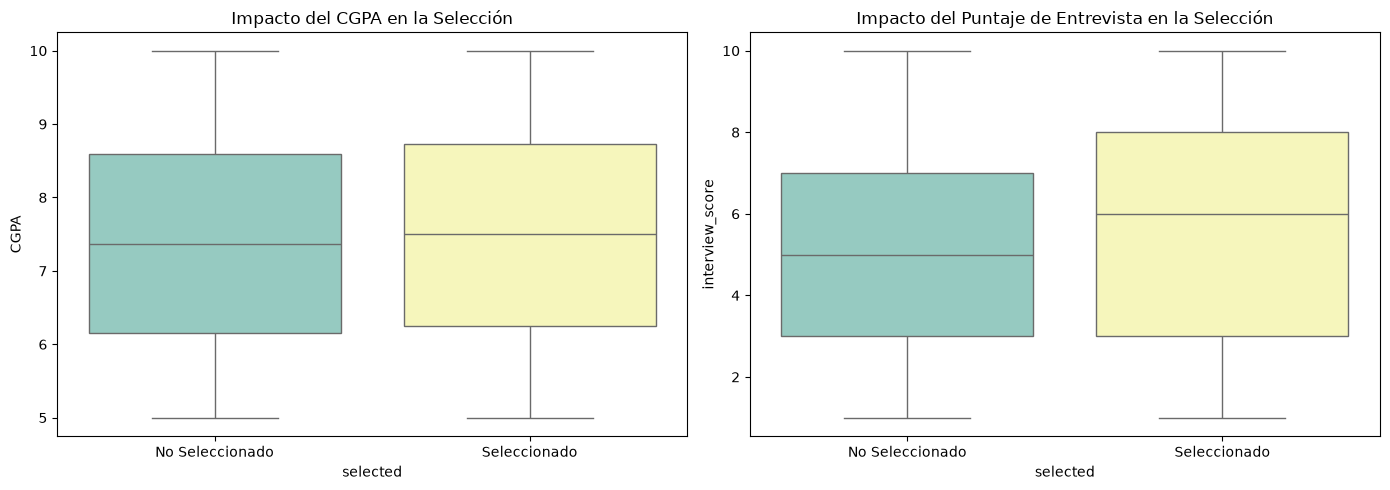

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='selected', y='CGPA', hue='selected', data=df, ax=axes[0], palette='Set3', legend=False)
axes[0].set_title('Impacto del CGPA en la Selección')
axes[0].set_xticklabels(['No Seleccionado', 'Seleccionado'])

sns.boxplot(x='selected', y='interview_score', hue='selected', data=df, ax=axes[1], palette='Set3', legend=False)
axes[1].set_title('Impacto del Puntaje de Entrevista en la Selección')
axes[1].set_xticklabels(['No Seleccionado', 'Seleccionado'])

plt.tight_layout()
plt.show()

### 💡 Interpretación de Relaciones con la Selección (Boxplots)
- **CGPA vs. Selección:** Curiosamente, las cajas (que representan el 50% central de los datos) y las medianas (la línea central del gráfico) para estudiantes seleccionados y no seleccionados están muy a la par. Esto indica que **tener un promedio alto (CGPA) no te garantiza la selección**, y tenerlo bajo no te descalifica automáticamente.
- **Puntaje de Entrevista vs. Selección:** Se observa una ligera tendencia de medianas más altas en los estudiantes seleccionados, indicando que el desempeño en la entrevista tiene un peso sutilmente mayor o más directo en la decisión final que el simple promedio académico.

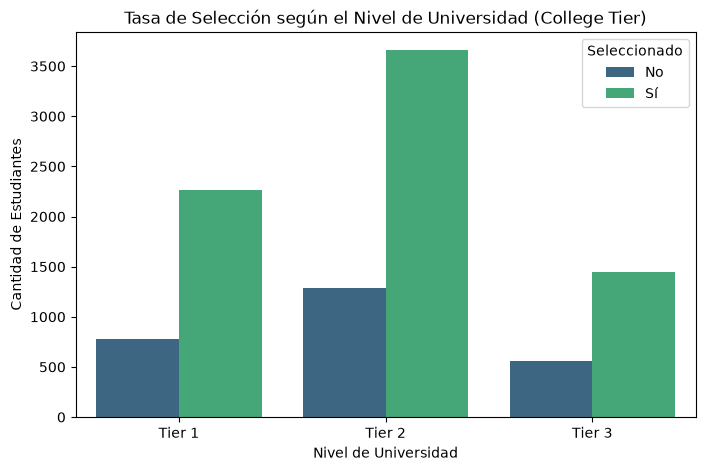

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='college_tier', hue='selected', data=df, order=['Tier 1', 'Tier 2', 'Tier 3'], palette='viridis')
plt.title('Tasa de Selección según el Nivel de Universidad (College Tier)')
plt.xlabel('Nivel de Universidad')
plt.ylabel('Cantidad de Estudiantes')
plt.legend(title='Seleccionado', labels=['No', 'Sí'])
plt.show()

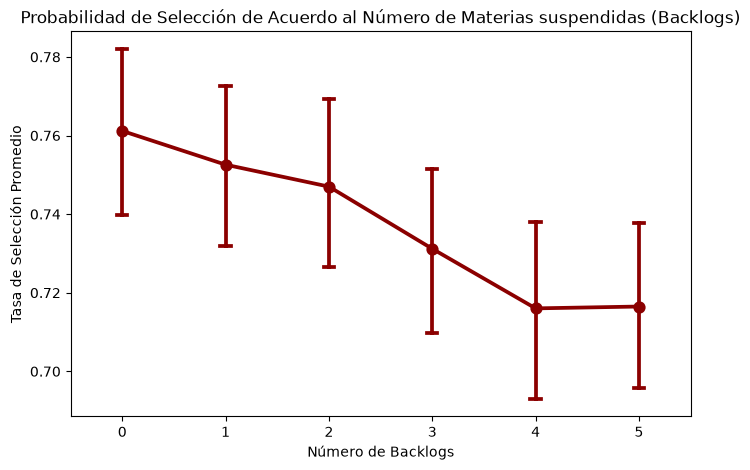

In [12]:
plt.figure(figsize=(8, 5))
sns.pointplot(x='backlogs', y='selected', data=df, color='darkred', capsize=0.1)
plt.title('Probabilidad de Selección de Acuerdo al Número de Materias suspendidas (Backlogs)')
plt.xlabel('Número de Backlogs')
plt.ylabel('Tasa de Selección Promedio')
plt.show()

### 💡 Interpretación del Impacto de las Materias Reprobadas
El gráfico de puntos (pointplot) muestra una tendencia clara y esperada: **a medida que aumenta el número de materias reprobadas (backlogs), la probabilidad promedio de ser seleccionado tiende a disminuir.** Sin embargo, es importante notar que la caída no es absoluta a cero, lo que implica que las empresas evalúan el perfil de forma holística. Un estudiante con backlogs aún puede ser seleccionado si compensa con otras habilidades (como proyectos, hackathons o pruebas de código).

## 4. Matriz de Correlación
Calcularemos y visualizaremos la correlación lineal de Pearson entre todas las variables numéricas del dataset para ver qué factores están más asociados entre sí.

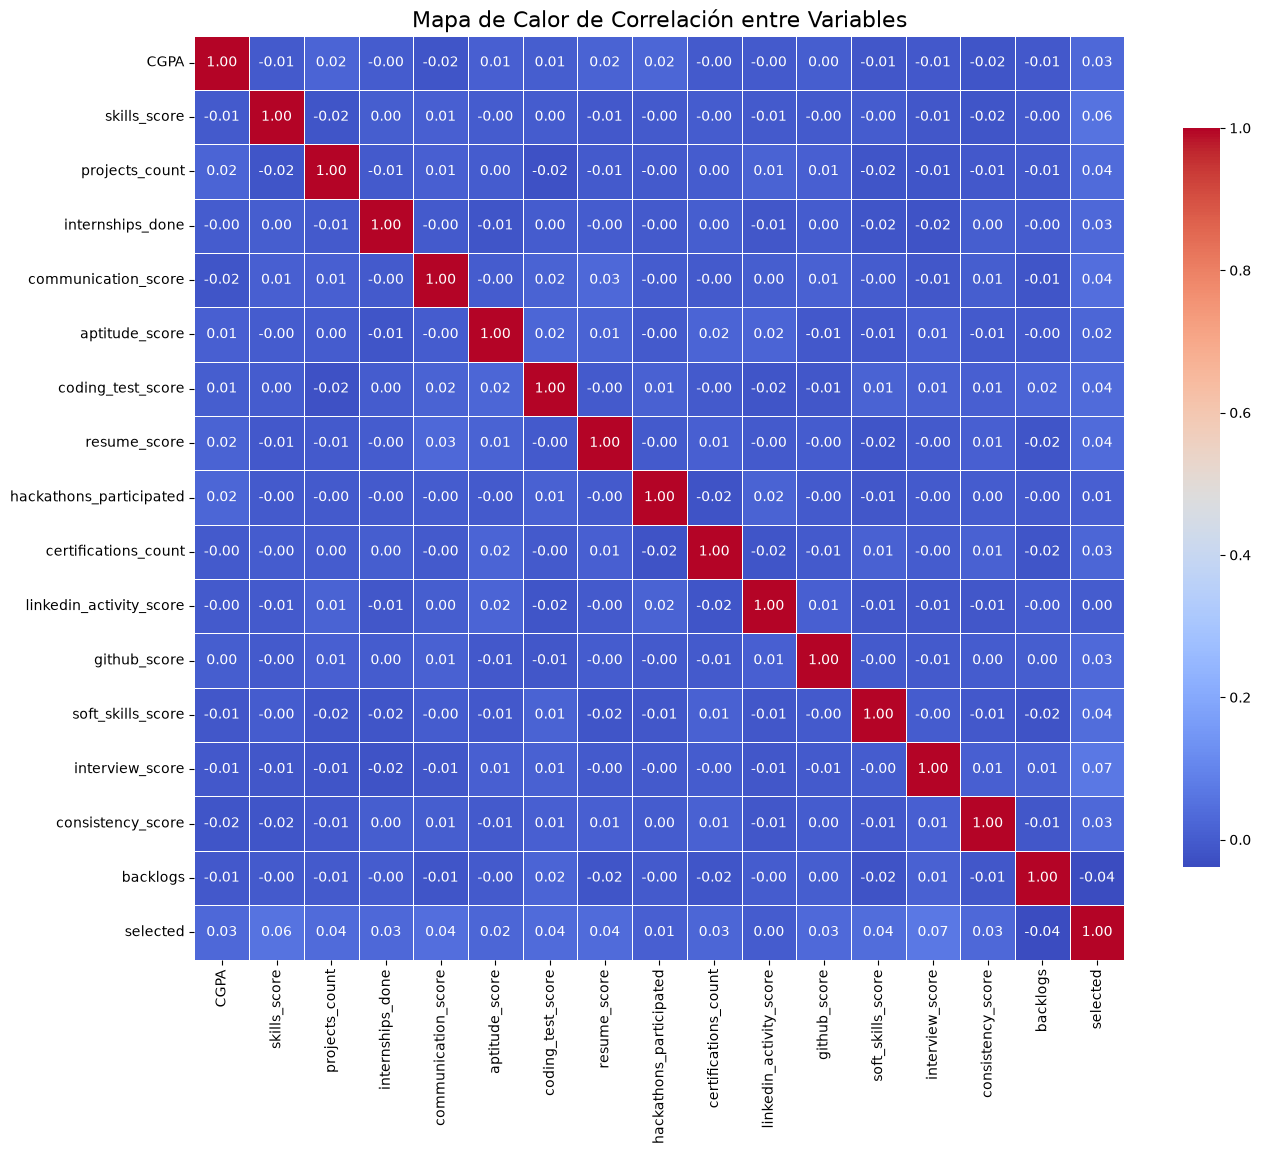

In [14]:
numeric_cols = df.select_dtypes(include='number').drop(columns=['student_id'])

corr_matrix = numeric_cols.corr()

# Dibujar el mapa de calor
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de Correlación entre Variables', fontsize=16)
plt.show()

### 💡 Interpretación de la Matriz de Correlación
- **Correlaciones Lineales Débiles:** Ninguna de las variables individuales tiene una correlación lineal fuerte (cercana a 1 o -1) con la variable objetivo `selected`. Las más altas apenas rondan el `0.06` o `0.07` (como *interview_score* o *skills_score*). 
- **Conclusión Clave:** Esto **NO** significa que las variables no sirvan. Significa que el proceso de selección de pasantes es **multidimensional y no lineal**. Un reclutador no decide basándose únicamente en una métrica que sube proporcionalmente. Deciden basándose en una combinación de factores (ej. "Si tiene poco CGPA pero muchos proyectos y buena entrevista, entra"). 
- **Siguientes Pasos:** Debido a la falta de linealidad, los modelos como Regresión Logística podrían quedarse cortos. Será muy recomendable utilizar algoritmos basados en árboles de decisión (como *Random Forest*, *Decision Trees* o *Gradient Boosting*), los cuales son excelentes para capturar estas reglas complejas y combinaciones de atributos.


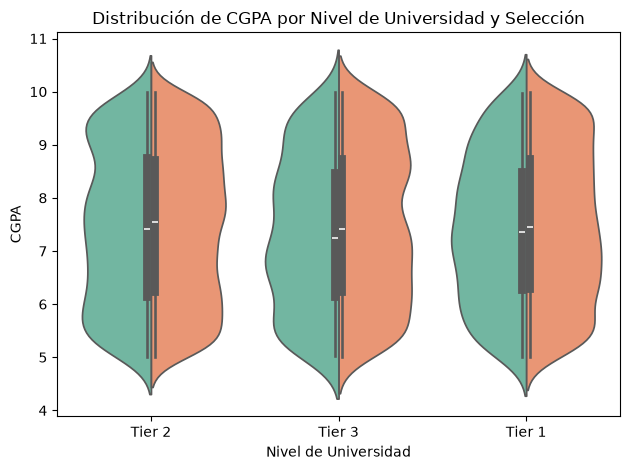

In [15]:

sns.violinplot(x='college_tier', y='CGPA', hue='selected', data=df, palette='Set2', legend=False, split=True)
plt.title('Distribución de CGPA por Nivel de Universidad y Selección')
plt.xlabel('Nivel de Universidad')
plt.ylabel('CGPA')


plt.tight_layout()
plt.show()

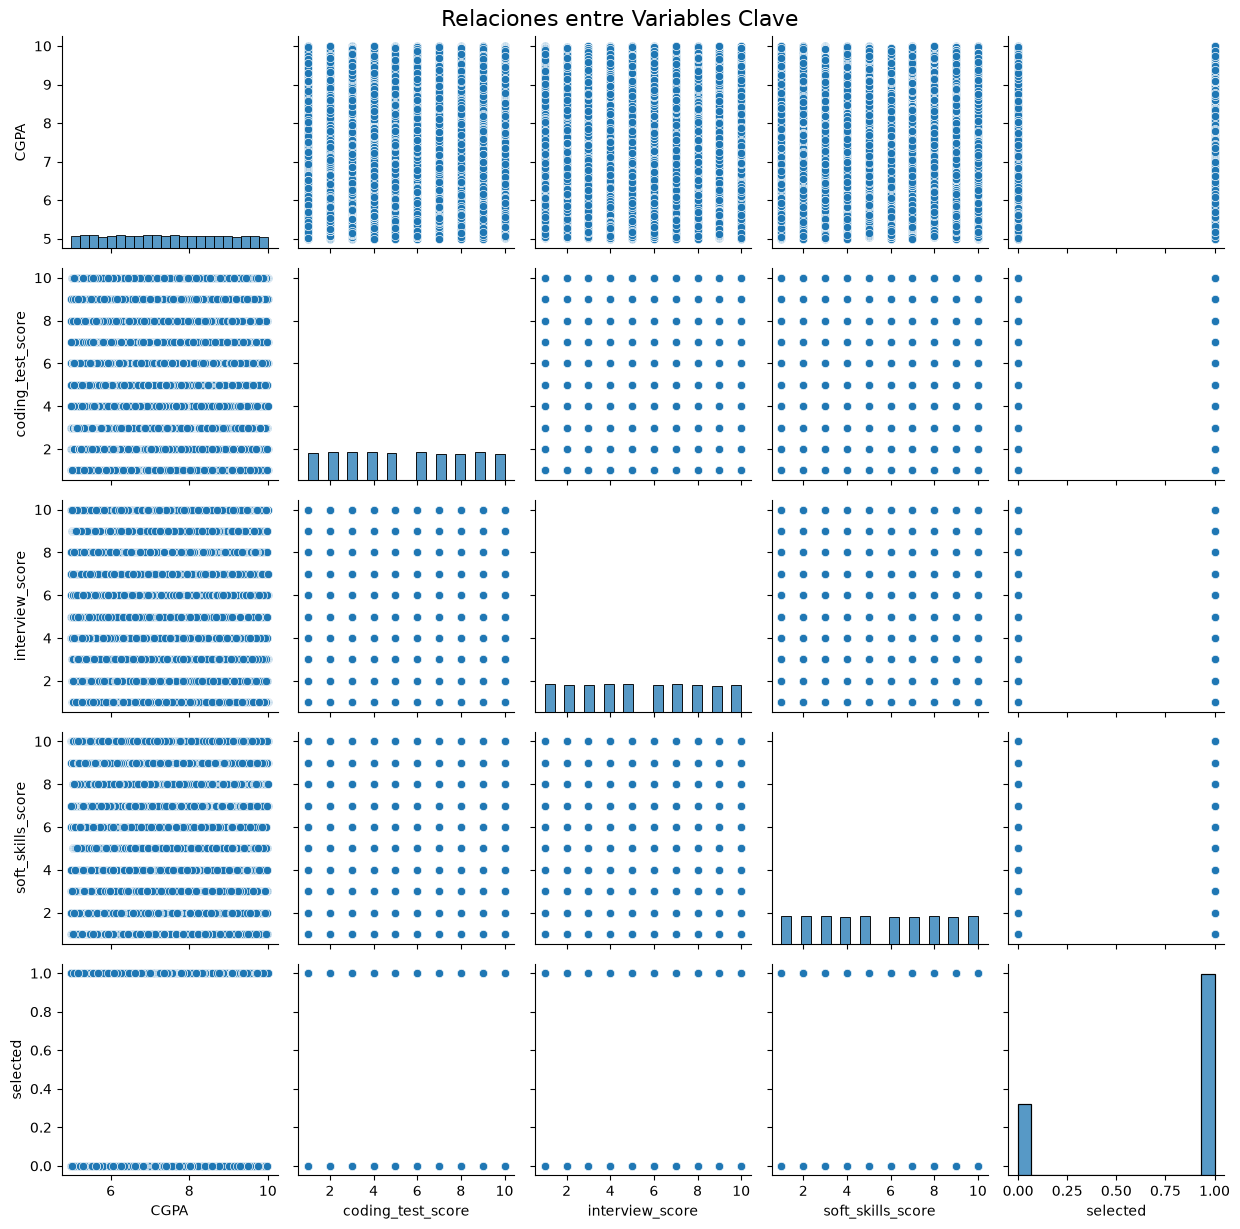

In [16]:
columnas_clave = ['CGPA', 'coding_test_score', 'interview_score', 'soft_skills_score', 'selected']
sns.pairplot(df[columnas_clave])
plt.suptitle('Relaciones entre Variables Clave', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Conclusiones Principales del EDA
- **Balance del dataset:** El ~73.7% de los estudiantes del dataset terminaron siendo seleccionados (`selected` = 1), lo que nos indica un dataset moderadamente desbalanceado hacia la clase positiva.
- **Ausencia de Nulos:** Los datos se encuentran completamente limpios sin valores faltantes ni duplicados.
- **Correlaciones débiles individuales:** Al observar el mapa de calor, las correlaciones lineales individuales con `selected` son relativamente bajas. Esto nos sugiere que la decisión de selección final podría depender de una combinación compleja y no estrictamente lineal de factores (como un conjunto integrado de habilidades técnicas, proyectos y rendimiento en entrevistas), ideal para algoritmos de Machine Learning no lineales (como Random Forest o XGBoost).